<a href="https://colab.research.google.com/github/Srishti6125/CURRENCY-CONVERTER/blob/main/airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



**Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name -** SRISHTI SINGHAL


# **Project Summary -**

Write the summary here within 500-600 words.

Airbnb is a global online marketplace that connects travelers with hosts offering unique stays, from single rooms to entire homes.

This project involved a comprehensive exploratory data analysis (EDA) of an Airbnb dataset containing various attributes about listings, hosts, locations, prices, availability, and review trends. The primary objective was to derive actionable insights by cleaning, transforming, and visualizing the dataset using Python (Pandas, Seaborn, Matplotlib, etc.).

🎯 Key Objectives:

* Clean and preprocess the dataset (handle missing values, outliers, and formatting)
* Perform data wrangling (feature engineering, binning, date parsing)
* Visualize key patterns using meaningful charts
* Identify trends in pricing, availability, and review behavior across room types and locations

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

Airbnb dataset

#### **Define Your Business Objective?**

The aim of this project is to dive into Airbnb listings data to reveal important patterns and insights that can support better decision-making for hosts, travelers, and everyone involved with the platform. By looking closely at pricing trends, availability, host behavior, and customer engagement (through reviews), we want to pinpoint what affects listing performance, fine-tune pricing strategies, and improve the overall user experience on Airbnb.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [ ]:
# Load Dataset
path = "/content/drive/MyDrive/Colab Notebooks/dataset/Copy of Airbnb NYC 2019.csv"
df = pd.read_csv(path)

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(48895, 16)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum().reset_index().rename(columns={'index': 'Column Name', 0: 'Null Value Count'})

,Column Name,Null Value Count
0,id,0
1,name,16
2,host_id,0
3,host_name,21
4,neighbourhood_group,0
5,neighbourhood,0
6,latitude,0
7,longitude,0
8,room_type,0
9,price,0


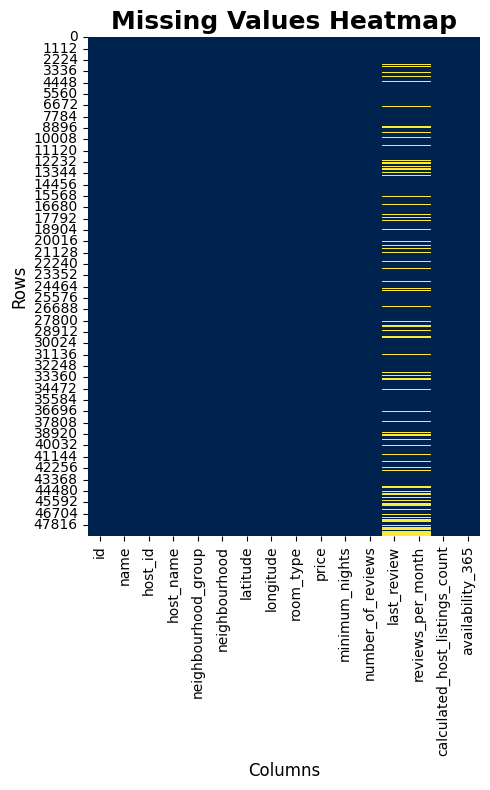

In [ ]:
# Visualizing the missing values

plt.figure(figsize=(5,8))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='cividis',
)
plt.title('Missing Values Heatmap', fontsize=18, fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows', fontsize=12)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset given is a dataset of Airbnbs, and we have to analyse the listings based on review, location, room type and through reviews and other insights behind it.

The above dataset has 48895 rows and 16 columns. There are no duplicate values in the dataset, whereas , null values are present in column name, host_name, last_review and reviews_per_month

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Variables Description

id : id of listing (airbnb)

name : name of listing (airbnb)

host_id : id of host of listing (airbnb)

host_name : name of host of listing (airbnb)

neighbourhood_group : neighbourhood_group where listing is located

neighbourhood : neighbouhood in neighbourhood_group where listing is located

latitude : latitude of airbnb

longitude : longitude of airbnb

room_type : type of room available in airbnb

price : price of listing per night

minimum_nights : minmum nights a person has to stay at listing

number_of_reviews : number of times airbnb is reviewed

last_review : date the listing is last reviewed

reviews_per_month : ratio of reviews per month

calculated_host_listings_count : number of other listings owned by the host

availability_365 : number of days the airbnb is available for

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique().reset_index().rename(columns={'index': 'Column Name', 0: 'Unique Values'})

,Column Name,Unique Values
0,id,48895
1,name,47905
2,host_id,37457
3,host_name,11452
4,neighbourhood_group,5
5,neighbourhood,221
6,latitude,19048
7,longitude,14718
8,room_type,3
9,price,674


## 3. ***Data Wrangling***

In [ ]:
#total missing values present in dataset
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# replacing null values with 'unknown' in host_name and name as these are small in number

df['host_name'] = df['host_name'].fillna('unknown')
df['name'] = df['name'].fillna('unknown')

# here, we are not replacing null values in last_review ans reviews_per_month as these are comparatively larger in number

In [ ]:
# changing data type of last_review from object to datetime

df['last_review'] = pd.to_datetime(df['last_review'])

In [ ]:
# neighbourhood_group loactions where airbnb are present

df['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


In [ ]:
# Total neighbourhoods in each neighbourhood_group where airbnb is present

for group in df['neighbourhood_group'].unique():
    print(f"\nNeighbourhoods in {group} : {df[df['neighbourhood_group'] == group]['neighbourhood'].nunique()}")


Neighbourhoods in Brooklyn : 47

Neighbourhoods in Manhattan : 32

Neighbourhoods in Queens : 51

Neighbourhoods in Staten Island : 43

Neighbourhoods in Bronx : 48


In [ ]:
#northmost latitude and southmost latitude where airbnb is located

print("Northern most latitude : ",df['latitude'].min())
print("Southern most latitude : ",df['latitude'].max())

Northern most latitude :  40.49979
Southern most latitude :  40.91306


In [ ]:
#eastnmost latitude and westmost latitude where airbnb is located

print("Eastern most latitude : ",df['longitude'].min())
print("Western most latitude : ",df['longitude'].max())

Eastern most latitude :  -74.24442
Western most latitude :  -73.71299


In [ ]:
#Total Area covering airbnbs in New York city
# 1deg latitude = 111 km
# 1deg longitude = 111.32 km

length = (df['latitude'].max() - df['latitude'].min()) * 111
breadth = (df['longitude'].max() - df['longitude'].min()) * 111.32
print("Area covering airbnbs in NewYork city :",length * breadth,"km")

Area covering airbnbs in NewYork city : 2713.7892888112015 km


In [ ]:
# different types of room available

df['room_type'].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


In [ ]:
#min and max price of airbnb per day

print("Minimum price of airbnb per day : ",df['price'].min())
print("Maximum price of airbnb per day : ",df['price'].max())

Minimum price of airbnb per day :  0
Maximum price of airbnb per day :  10000


In [ ]:
# adding a new column minimum_price - it tells us about the minimum price one can book a particular airbnb for

df['minimum_price'] = df['minimum_nights'] * df['price']

In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,minimum_price
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,149
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,225
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,450
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,89
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,800


In [ ]:
#sorting dataset based on minimum_price

df.sort_values(by='minimum_price')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,minimum_price
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaT,NaN,1,0,0
26866,21304320,Best Coliving space ever! Shared room.,101970559,Sergii,Brooklyn,Bushwick,40.69166,-73.90928,Shared room,0,30,5,2019-05-24,0.26,6,139,0
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0,0
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44429,34221161,Room with sofa bed or air mattress,9295237,Noelle,Queens,Astoria,40.75593,-73.91276,Private room,2000,365,0,NaT,NaN,2,0,730000
17811,13963005,Gorgeous 2 Bedroom apartment,41870118,Iveta,Queens,Forest Hills,40.72064,-73.83746,Entire home/apt,2350,365,0,NaT,NaN,1,364,857750
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",3906464,Amy,Manhattan,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,2016-01-01,0.14,1,83,989901
9151,7003697,Furnished room in Astoria apartment,20582832,Kathrine,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0,1000000


In [ ]:
# getting the minimum price and maximum price at which particualar airbnb is available

print("Minimum price at which airbnb is available : ",df['minimum_price'].min())
print("Maximum price at which airbnb is available : ",df['minimum_price'].max())

Minimum price at which airbnb is available :  0
Maximum price at which airbnb is available :  1170000


In [ ]:
# list of all airbnbs with 0 price

print("List of airbnbs with 0 price : ",df[df['price'] == 0]['name'].unique())

List of airbnbs with 0 price :  ['Huge Brooklyn Brownstone Living, Close to it all.'
 '★Hostel Style Room | Ideal Traveling Buddies★'
 'MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)'
 'Sunny, Quiet Room in Greenpoint'
 'Modern apartment in the heart of Williamsburg'
 'Spacious comfortable master bedroom with nice view'
 'Contemporary bedroom in brownstone with nice view'
 'Cozy yet spacious private brownstone bedroom' 'the best you can find'
 'Coliving in Brooklyn! Modern design / Shared room'
 'Best Coliving space ever! Shared room.']


In [ ]:
# adding column specifying the category of price i.e. low,medium,high

df['price_category'] = pd.cut(df['price'],
                              bins=[-1, 1000, 3000, df['price'].max()],
                              labels=['Low', 'Medium', 'High'])

# low : 0 - 1000
# medium : 1001-3000
# high : 3001-max

In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,minimum_price,price_category
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,149,Low
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,225,Low
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,450,Low
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,89,Low
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,800,Low


In [ ]:
#min and max no of nights a person can book an airbnb for the min time

print("Smallest required stay: : ",df['minimum_nights'].min())
print("Largest required stay: : ",df['minimum_nights'].max())

Smallest required stay: :  1
Largest required stay: :  1250


In [ ]:
# max and min number of times listing is reviewed

print("Minimum number of times listing is reviewed : ",df['number_of_reviews'].min())
print("Maximum number of times listing is reviewed : ",df['number_of_reviews'].max())

Minimum number of times listing is reviewed :  0
Maximum number of times listing is reviewed :  629


In [ ]:
# number of airbnb with min reviews

print("Total number of airbnb with min reviews : ",df[df['number_of_reviews'] == df['number_of_reviews'].min()]['name'].nunique())
print("Total number of airbnb with max reviews : ",df[df['number_of_reviews'] == df['number_of_reviews'].max()]['name'].nunique())

Total number of airbnb with min reviews :  9885
Total number of airbnb with max reviews :  1


In [ ]:
#most reviewed airbnb

print("Most reviewed airbnb : ",df[df['number_of_reviews'] == df['number_of_reviews'].max()]['name'].unique())

Most reviewed airbnb :  ['Room near JFK Queen Bed']


In [ ]:
# Fill reviews_per_month with 0 where number_of_reviews is 0

df.loc[df['number_of_reviews'] == 0, 'reviews_per_month'] = 0

In [ ]:
#finding timeperiod to which this dataset belongs to

print("Dataset covers information from year",int(df['last_review'].dt.year.min()),"to",int(df['last_review'].dt.year.max()))

Dataset covers information from year 2011 to 2019


In [ ]:
#adding a new column specifying no of days each airbnb is last reviewed

from datetime import date

df['days_till_last_review'] = pd.to_datetime(date.today()) - df['last_review']

In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,minimum_price,price_category,days_till_last_review
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,149,Low,2448 days
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,225,Low,2234 days
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,450,Low,NaT
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,89,Low,2189 days
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,800,Low,2417 days


In [ ]:
# number of days until today airbnbs last reviewd

print("Number of days until today airbnbs last reviewd : ",df['days_till_last_review'].min())

Number of days until today airbnbs last reviewd :  2186 days 00:00:00


In [ ]:
#max and min number of reviews obtained per month

print("Maximum reviews obtained per month : ",df['reviews_per_month'].max())
print("Minimum reviews obtained per month : ",df['reviews_per_month'].min())

Maximum reviews obtained per month :  58.5
Minimum reviews obtained per month :  0.0


In [ ]:
#max and min no of listing owned by host

print("Maximum listing owned by host : ",df['calculated_host_listings_count'].max())
print("Minimum listing owned by host : ",df['calculated_host_listings_count'].min())

Maximum listing owned by host :  327
Minimum listing owned by host :  1


In [ ]:
# list of host with max no of listing

print("List of host with max no of listinng : ",df[df['calculated_host_listings_count'] == df['calculated_host_listings_count'].max()]['host_name'].unique())

List of host with max no of listinng :  ['Sonder (NYC)']


In [ ]:
# no of airbnbs available for 0 days and 365 days

print("List of airbnbs not available : ",df[df['availability_365'] == 0]['name'].nunique())
print("List of airbnbs available for whole year : ",df[df['availability_365'] == 365]['name'].nunique())

List of airbnbs not available :  17256
List of airbnbs available for whole year :  1273


### Data Wrangling Code

### What all manipulations have you done and insights you found?

We added three more new columns -

* *minimum_price* : minimum price person has to pay to book a particular listing
* *price_category* : specifies the price category to which airbnb belongs to
*  *days_till_last_review* : no of days until the listing is last reviewed


Also, we replaced null values in *name* and *host_name* to unknown.

We replaced *reviews_per_month* = 0 where *number_of_reviews* = 0 .

Calculated the area covering mentioned listings : 2713.7892888112015 km

Along ,  with timeperiod to which this dataset belongs to i.e. from **2011 - 2019**.

and other insights :

***private room*** amd ***entire home/apt*** are preferred more over ***shared room***

***Manhattan*** is the neighbouhood group with most listings i.e. 21661
whereas ,  last stands the ***Staten Island*** with list number of listings i.e.	373.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


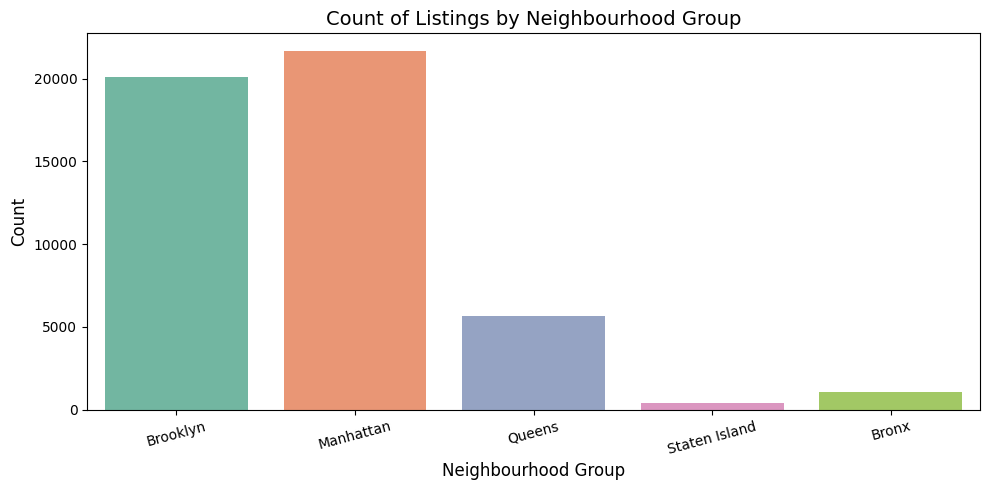

In [ ]:
# Chart - 1 visualization code

# distribution of airbnbs in neighbourhoud_group

print(df['neighbourhood_group'].value_counts())

plt.figure(figsize=(10, 5))

sns.countplot(
    x='neighbourhood_group',
    data=df,
    palette='Set2',hue='neighbourhood_group',legend=False
)

plt.title("Count of Listings by Neighbourhood Group", fontsize=14)
plt.xlabel("Neighbourhood Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar charts show the frequency counts of values for the different levels of a categorical or nominal variable. Sometimes, bar charts show other statistics, such as percentages.

##### 2. What is/are the insight(s) found from the chart?

Manhattan is the neighbourhood_group with most number of listings i.e. 21661
whereas, the Staten Island has the least number of listings, are 373 in number

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since, Manhattan and brooklyn has most nunmber of listings, therefore we can say that these must be the most visited places.

Staten Island has least number of listings may be due to least visited place because of the distance compared to other neighbourhood groups

#### Chart - 2

  neighbourhood_group  unique_review_counts
0               Bronx                   148
1            Brooklyn                   318
2           Manhattan                   325
3              Queens                   275
4       Staten Island                   103


/tmp/ipython-input-48-751987507.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


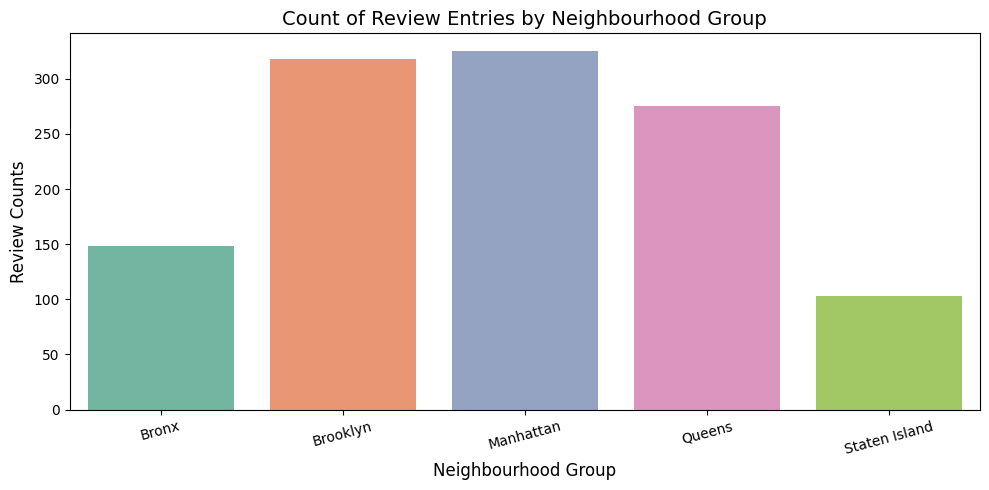

In [ ]:
# Chart - 2 visualization code

# neighbourhoud_groups with most number of reviews
data = df.groupby('neighbourhood_group')['number_of_reviews'].nunique().reset_index()
data.columns = ['neighbourhood_group', 'unique_review_counts']

print(data)

plt.figure(figsize=(10, 5))
sns.barplot(
    x='neighbourhood_group',
    y='unique_review_counts',
    data=data,
    palette='Set2'
)

plt.title("Count of Review Entries by Neighbourhood Group", fontsize=14)
plt.xlabel("Neighbourhood Group", fontsize=12)
plt.ylabel("Review Counts", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts show the frequency counts of values for the different levels of a categorical or nominal variable. Sometimes, bar charts show other statistics, such as percentages.

##### 2. What is/are the insight(s) found from the chart?

Manhattan is the neighbourhood_group with most number of reviews
whereas, the Staten Island has the least number of reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since, Manhattan, brooklyn and Queens has most nunmber of reviews, therefore we can say that these are the most visited places.

Staten Island has least number of listings may be due to least visited place because of the distance compared to other neighbourhood groups

#### Chart - 3

  neighbourhood_group  total_listings  total_reviews
0               Bronx            1091          28371
1            Brooklyn           20104         486574
2           Manhattan           21661         454569
3              Queens            5666         156950
4       Staten Island             373          11541


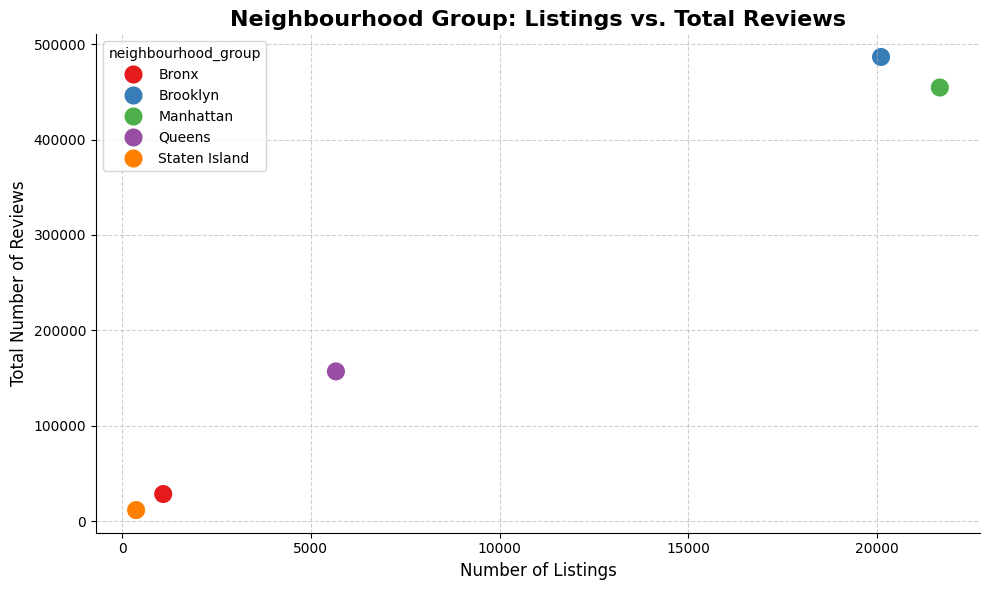

In [ ]:
# Chart - 3 visualization code

# number of listing vs number of reviews (based on neighbourhood_groups)

grouped = df.groupby('neighbourhood_group').agg(
    total_listings=('id', 'count'),
    total_reviews=('number_of_reviews', 'sum')
).reset_index()
print(grouped)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=grouped,
    x='total_listings',
    y='total_reviews',
    hue='neighbourhood_group',
    s=200,  # bubble size
    palette='Set1'
)

# Annotate points
"""for i in range(len(grouped)):
    plt.text(grouped['total_listings'][i] + 10,
             grouped['total_reviews'][i] + 10,
             grouped['neighbourhood_group'][i],
             fontsize=9)"""

# Styling
plt.title("Neighbourhood Group: Listings vs. Total Reviews", fontsize=16, fontweight='bold')
plt.xlabel("Number of Listings", fontsize=12)
plt.ylabel("Total Number of Reviews", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot because it’s the most effective way to visualize the relationship between two continuous variables — in this case:

Number of listings per neighbourhood group (supply)

Total number of reviews (demand or guest engagement)

Each dot represents a neighbourhood_group, and the color hue adds a visual cue to identify which group it belongs to. This makes the scatter plot simple, clear, and powerful for quickly spotting outliers, clusters, and trends across neighbourhood groups.

##### 2. What is/are the insight(s) found from the chart?

Neighbourhood groups with more listings also tend to have more total reviews — indicating strong demand in those high-supply areas.

Some neighbourhoods had high listing counts but relatively fewer reviews, suggesting lower engagement per listing — possibly due to competition or listing fatigue.

A few neighbourhoods with fewer listings but relatively high review counts suggest high guest interest and potential for growth.

##### 3. Will the gained insights help creating a positive business impact?


Are there any insights that lead to negative growth? Justify with specific reason

 Airbnb can encourage new hosts to list in areas with low supply but strong demand, improving platform-wide efficiency.

New hosts can avoid oversaturated areas and target neighbourhoods with better guest engagement.

Areas with high demand but low listing count can be promoted more to expand inventory in high-conversion zones.

Neighbourhood groups with high listings but low total reviews suggest listings are not getting enough bookings or visibility.

#### Chart - 4

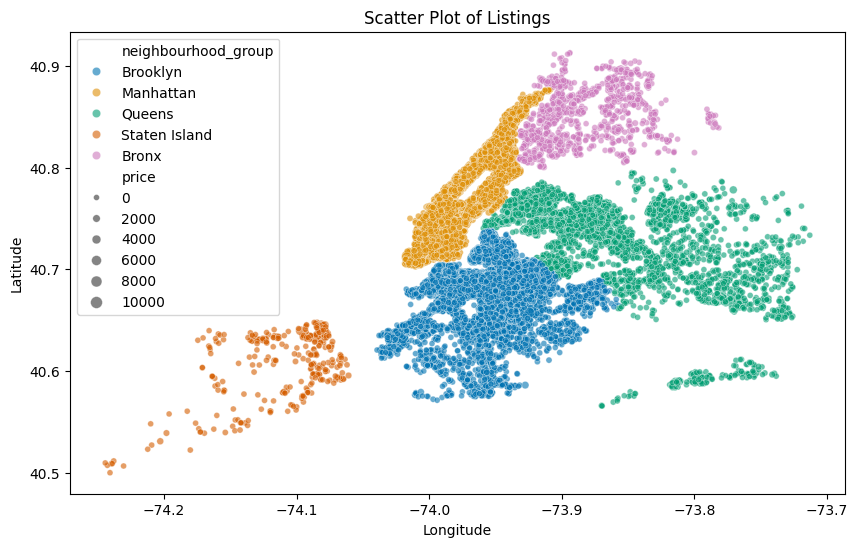

In [ ]:
# Chart - 4 visualization code

# distribution of airbnbs across NewYork city

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='neighbourhood_group',    # color by category
    size='price',                 # bubble size based on price
    palette='colorblind',
    alpha=0.6
)

plt.title("Scatter Plot of Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

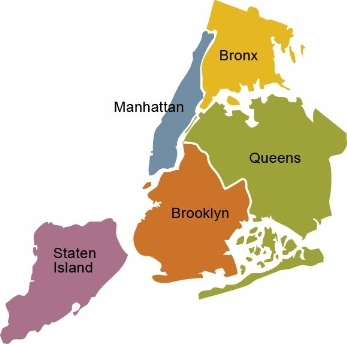

##### 1. Why did you pick the specific chart?

using scatter plot we can clearly and easily access the location where each listing is present in NewYork city.

##### 2. What is/are the insight(s) found from the chart?

Since, density of bubbles is less in Staten Island, we can say that least number of listings are present there.

This may be due to the location of Staten Island which is basically seperated from other neighbourhood_group and so there must be less visitors

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Customer can consider the neigbourhood to visit(Manhattan and Brooklyn) where they can get varied options to stay at acc to their needs and comfort.

#### Chart - 5

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


/tmp/ipython-input-52-999304142.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neighbourhoods.values,


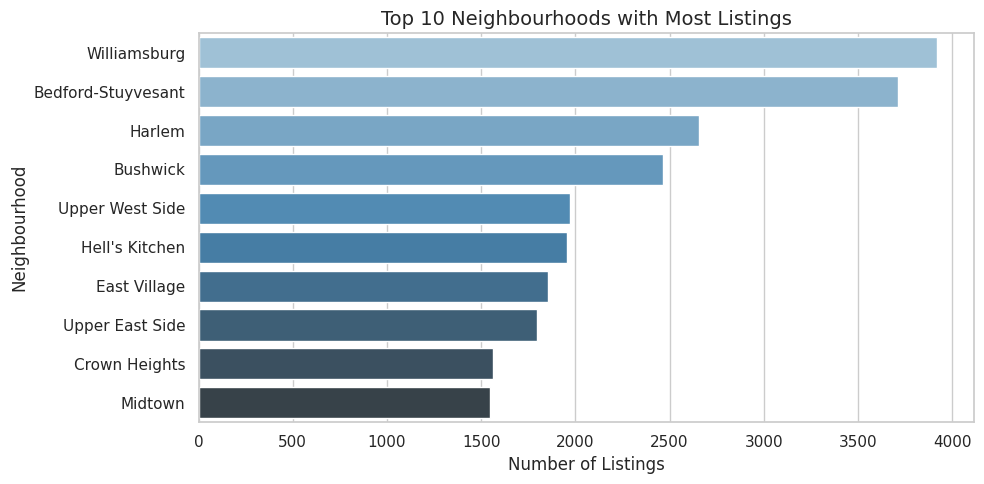

In [ ]:
# Chart - 5 visualization code

#Top 10 Neighbourhoods with Most Listings

top_neighbourhoods = df['neighbourhood'].value_counts().head(10)

print(top_neighbourhoods)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_neighbourhoods.values,
            y=top_neighbourhoods.index,
            palette="Blues_d",
            )
plt.title("Top 10 Neighbourhoods with Most Listings", fontsize=14)
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar charts show the frequency counts of values for the different levels of a categorical or nominal variable. Sometimes, bar charts show other statistics, such as percentages.

##### 2. What is/are the insight(s) found from the chart?

Williamsburg and Bedford - Stuyvesant are the neighbourhood with most listings

Answer Here.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since these are the places with most listings, it would be an advantage for visitors as many options are available for them to stay at, according to their needs such as room_type,quality and price range.

On the other hand, for a new host to open a new airbnb in these area would be a bad option as already many competitors are present at these places.


#### Chart - 6

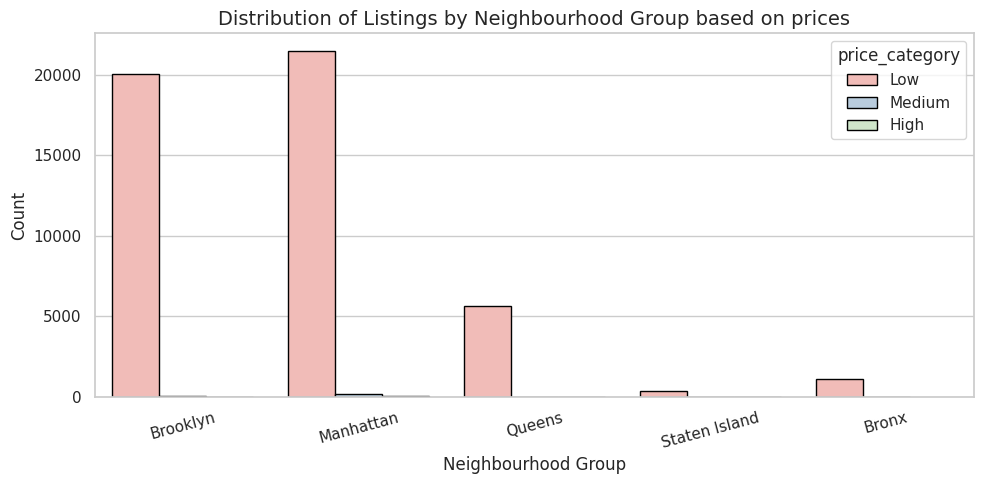

In [ ]:
# Chart - 6 visualization code

#Distribution of Listings by Neighbourhood Group based on prices
plt.figure(figsize=(10, 5))
sns.countplot(
    x='neighbourhood_group',
    data=df,
    palette='Pastel1',hue='price_category',edgecolor='black'
)

plt.title("Distribution of Listings by Neighbourhood Group based on prices", fontsize=14)
plt.xlabel("Neighbourhood Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

 Seaborn countplot with a hue because it's the most effective way to visualize categorical comparisons across two dimensions:

neighbourhood_group (x-axis) → represents different areas in the city

price_category (hue) → represents different pricing tiers (Low, Medium, High)

##### 2. What is/are the insight(s) found from the chart?

Some neighbourhood groups (e.g., Manhattan or central areas) may have a higher proportion of high-priced listings, indicating premium market segments.

Other groups (like Bronx or Queens, depending on the city) may show dominance in the low to medium price range, appealing to budget-conscious travelers.

Certain neighbourhoods might have a balanced mix of all three pricing categories, suggesting a diverse offering that appeals to a broader audience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Hosts can choose the right neighbourhood to list based on their pricing strategy (e.g., luxury in high-price zones, budget listings in low-price zones).

Airbnb can identify areas that need a better mix of listing types to cater to different audience segments.

If certain neighbourhood groups have only high-priced listings, they may be alienating budget travelers, limiting booking potential.

#### Chart - 7

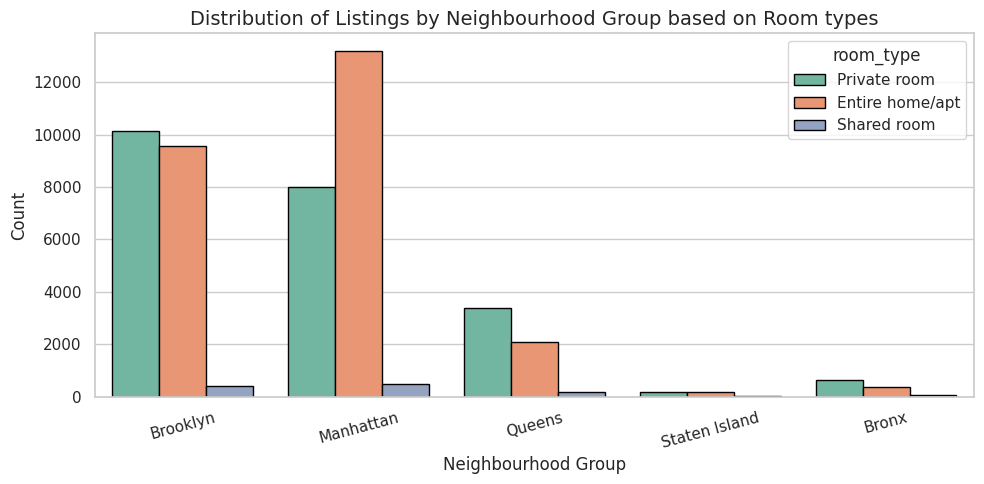

In [ ]:
# Chart - 7 visualization code

#Distribution of Listings by Neighbourhood Group based on prices
plt.figure(figsize=(10, 5))
sns.countplot(
    x='neighbourhood_group',
    data=df,
    palette='Set2',hue='room_type',edgecolor='black'
)

plt.title("Distribution of Listings by Neighbourhood Group based on Room types", fontsize=14)
plt.xlabel("Neighbourhood Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

 Seaborn countplot with a hue because it's the most effective way to visualize categorical comparisons across two dimensions:

neighbourhood_group (x-axis) → represents different areas in the city

room_type (hue) → represents different room_type(private room, shared room, entire room/apt)

##### 2. What is/are the insight(s) found from the chart?

Certain neighbourhood groups (e.g., Manhattan) likely have a dominance of entire homes/apartments, indicating a more premium or tourist-heavy area.

Other groups (e.g., Bronx or Queens) may have a higher proportion of private rooms, suggesting more budget-oriented or local-driven listings.

Shared rooms are rare across all areas, showing low popularity and possible guest discomfort with shared space.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Visitors can choose the right neighbourhood to list based on their comfort and privacy.

Hosts can list the right type of property based on what’s performing well in their neighbourhood.

If certain neighbourhood groups have only high-priced listings, they may be alienating budget travelers, limiting booking potential.

#### Chart - 8

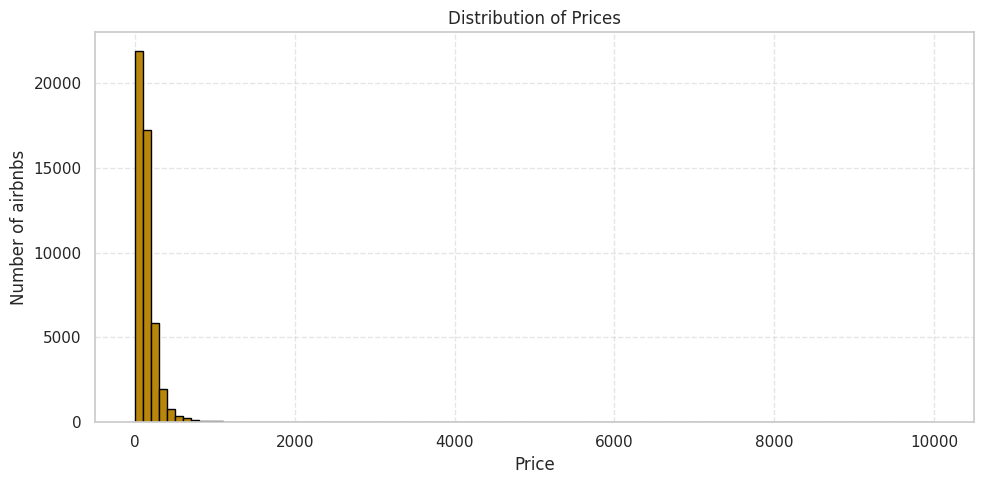

In [ ]:
# Chart - 8 visualization code

#price ranges

plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=100, color='darkgoldenrod', edgecolor='black')
plt.title('Distribution of Prices')
plt.xlabel('Price')
plt.ylabel('Number of airbnbs')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

histogram is the most effective chart to visualize the distribution of a continuous numerical variable — in this case, the price of Airbnb listings.

The histogram allows us to:See how prices are spread out and identify common price ranges

##### 2. What is/are the insight(s) found from the chart?

The distribution is right-skewed (a long tail of high prices), which is common in real-world pricing.

Most listings fall under a specific price range, typically between ₹0 and ₹3000 (depending on your dataset), indicating that the majority of Airbnb hosts are offering budget- to mid-range stays.

There are some extreme outliers (very high prices), possibly luxury listings or data anomalies.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Hosts can use this data to price competitively and align with market norms.

Helps Airbnb estimate guest affordability ranges and personalize search results accordingly.

The presence of extreme outliers (e.g., listings priced at ₹50,000 or more) could intimidate or mislead budget travelers

If too many listings are priced similarly, there could be undifferentiated competition, leading to pricing wars and poor host revenue.

#### Chart - 9

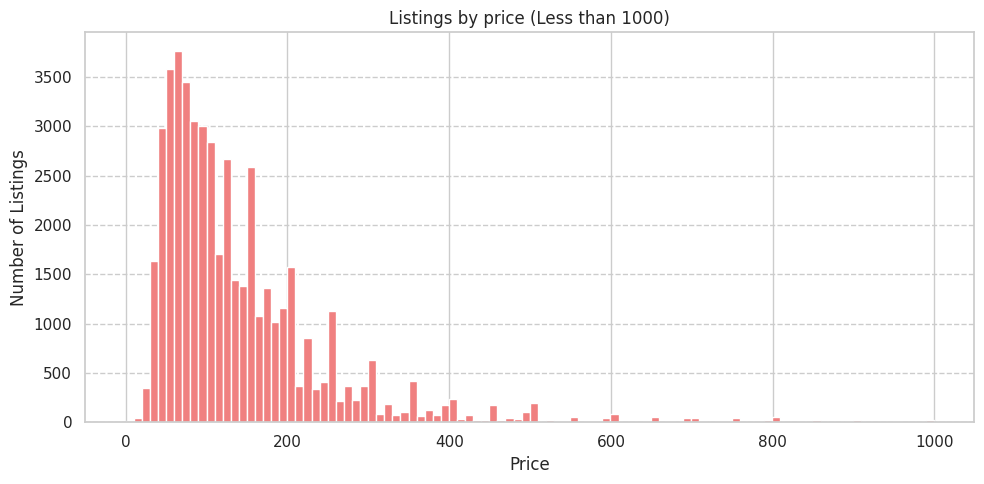

In [ ]:
# Chart - 9 visualization code

# no of listing with price range less than 1000

plt.figure(figsize=(10,5))
plt.hist(df[df['price'] < 1000]['price'], bins=100, color='lightcoral', edgecolor='white')
plt.title("Listings by price (Less than 1000)")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

histogram is the most effective chart to visualize the distribution of a continuous numerical variable — in this case, the price of Airbnb listings < 1000.

The histogram allows us to:See how prices are spread out and identify common price ranges

##### 2. What is/are the insight(s) found from the chart?

The distribution is right-skewed (a long tail of high prices)

Most listings fall under a specific price range indicating that the majority of Airbnb hosts are offering low and affordable budget stays.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Hosts can use this data to price competitively and align with market norms.

Helps Airbnb estimate guest affordability ranges and personalize search results accordingly.

If too many listings are priced similarly, there could be undifferentiated competition, leading to pricing wars and poor host revenue.

#### Chart - 10

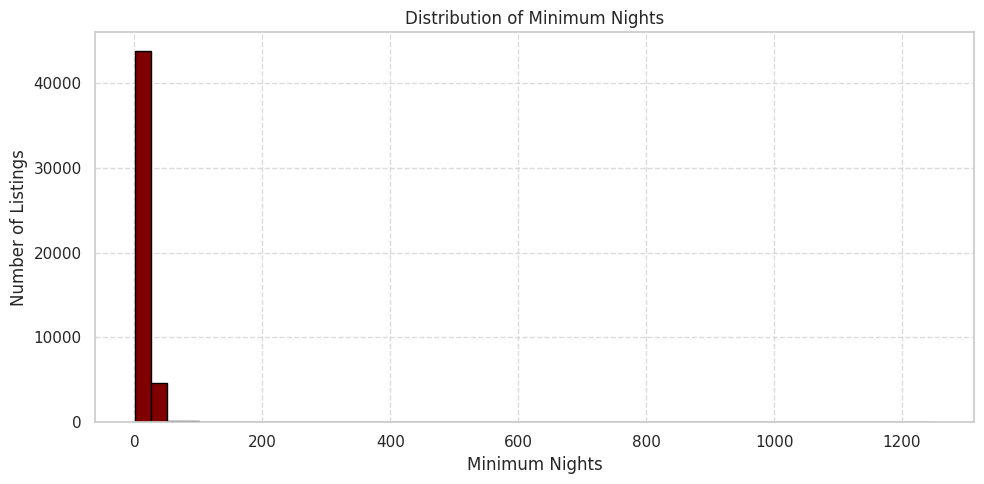

In [ ]:
# Chart - 10 visualization code

# no of listing with minimum_night

plt.figure(figsize=(10, 5))
plt.hist(df['minimum_nights'], bins=50, color='maroon', edgecolor='black')
plt.title('Distribution of Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Number of Listings')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

histogram is the most effective chart to visualize the distribution of a continuous numerical variable — in this case, count of minimum number of nights offered by Airbnb listings.


##### 2. What is/are the insight(s) found from the chart?

A huge spike at 1 or 2 nights, showing that most hosts allow short-term stays, which is great for travelers seeking flexibility.

Smaller peaks at 3, 7, and sometimes 30 — often aligned with weekend getaways or monthly rentals.

A long right tail (extreme values like 100, 365, etc.) which might be long-term rentals.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Airbnb can suggest optimal minimum_nights to new hosts (e.g., 1–3 nights) to attract more bookings.

Knowing that most listings allow short stays helps improve search results and recommendations for short-term travelers.

Listings with long minimum stays can be marketed as corporate housing or long-term vacation homes.

Extremely high values in minimum_nights could be: Barriers to bookings (guests may skip listings that demand 30+ nights), may lead to reduced visibility, especially in short-stay searches

#### Chart - 11

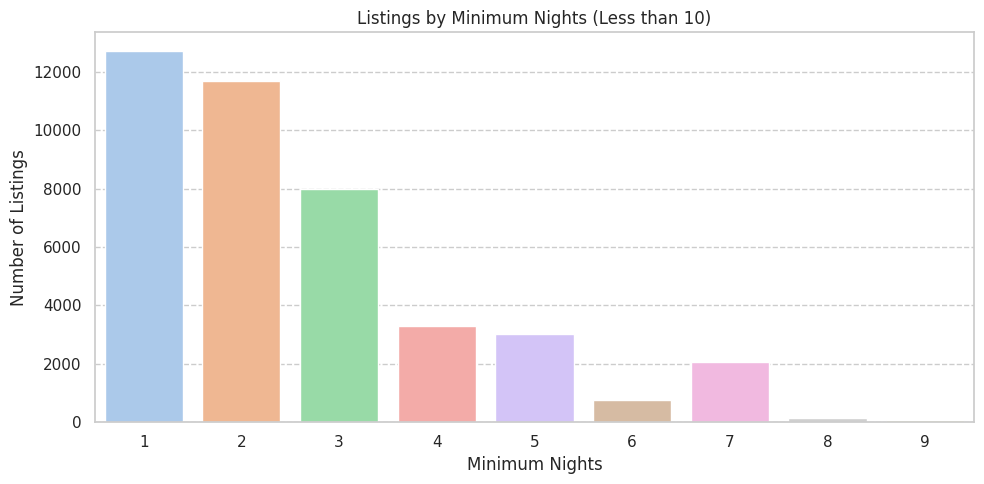

In [ ]:
# Chart - 11 visualization code

#Listings by Minimum Nights (Less than 10)

plt.figure(figsize=(10,5))
sns.countplot(data=df[df['minimum_nights'] < 10], x='minimum_nights', palette='pastel',
hue='minimum_nights',legend=False)
plt.title("Listings by Minimum Nights (Less than 10)")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar charts show the frequency counts of values for the different levels of a categorical or nominal variable. Sometimes, bar charts show other statistics, such as percentages.

##### 2. What is/are the insight(s) found from the chart?

A huge spike at 1 or 2 nights, showing that most hosts allow short-term stays, which is great for travelers seeking flexibility.

7 day stays are preferred, aligning to weekly trip

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Airbnb can suggest optimal minimum_nights to new hosts (e.g., 1–3 nights) to attract more bookings.

Knowing that most listings allow short stays helps improve search results and recommendations for short-term travelers.

#### Chart - 12

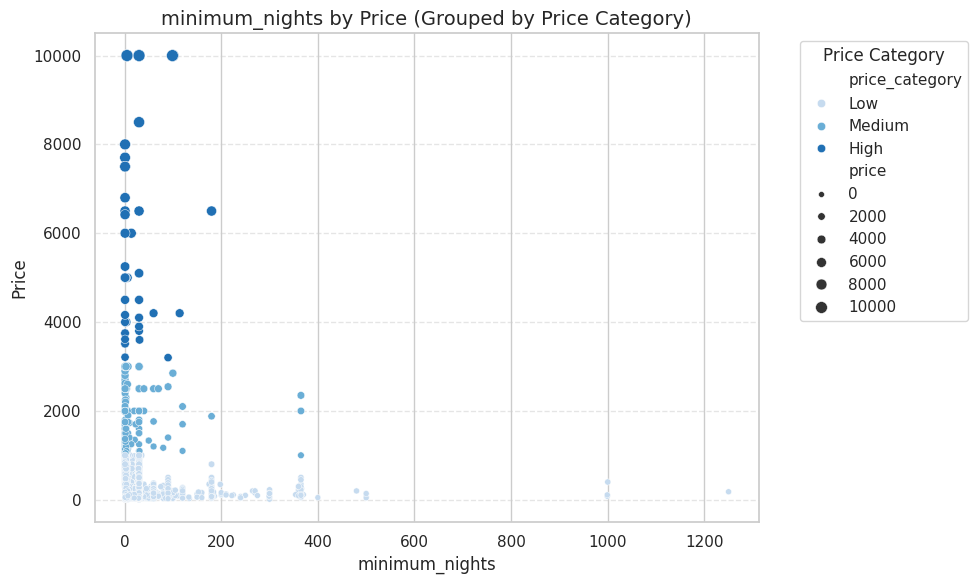

In [ ]:
# Chart - 12 visualization code

# minimum_nights by Price (Grouped by Price Category)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='minimum_nights',
    y='price',
    hue='price_category',
    palette='Blues',
    size='price'
)

plt.title("minimum_nights by Price (Grouped by Price Category)", fontsize=14)
plt.xlabel("minimum_nights", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend(title="Price Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot  is perfect for visualizing the relationship between two continuous variables — minimum_nights and price — while also using:

Hue to show the price_category (Low, Medium, High)

Size to highlight how high the prices go



##### 2. What is/are the insight(s) found from the chart?

Most low and medium-priced listings cluster around 1–7 minimum nights, indicating they are short-stay friendly.

High-priced listings tend to have wider variation in minimum_nights, with many requiring longer stays, possibly due to: Premium/luxury stays , Vacation villas
and Monthly rentals

A few outliers have extremely high minimum_nights with varying prices — possibly indicating long-term leases, data entry errors, or niche listings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Hosts offering high-end listings can set flexible minimum_nights to boost bookings.

Airbnb can recommend common price-night combinations to new hosts to avoid low-visibility listings.

Guests looking for short stays can avoid high minimum_nights, while long-term guests can focus on listings with longer requirements.


Listings with high price + high minimum_nights could struggle to get bookings due to being too restrictive, leading to: Lower conversion rates and poor visibility in default search results

#### Chart - 13

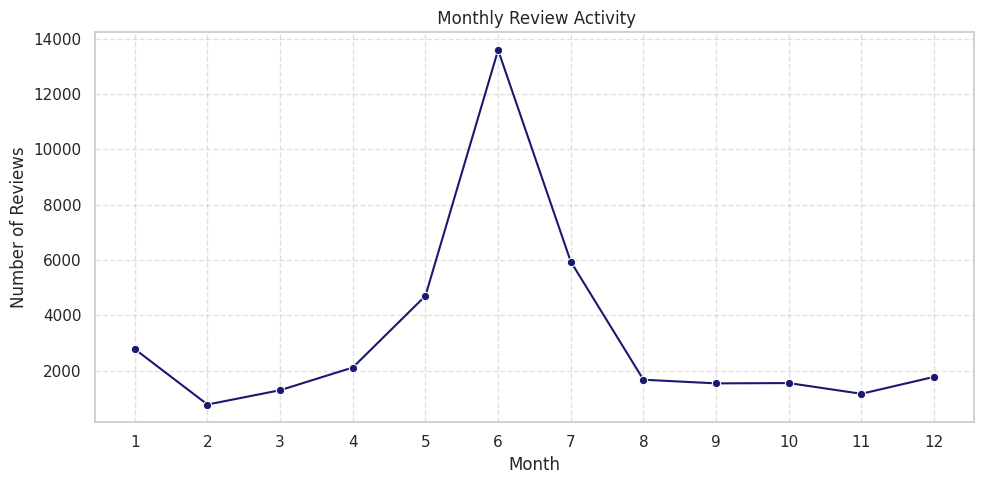

In [ ]:
# Chart - 13 visualization code

# visualizaing listing reviewed mostly in which month

month_counts = df['last_review'].dt.month.value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o', color='midnightblue')

plt.title(" Monthly Review Activity")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

line plot because is ideal for showing trends over a time-based sequence — in this case, months (1 to 12).
This chart clearly shows how the volume of reviews changes month to month, which is often a proxy for booking activity.

##### 2. What is/are the insight(s) found from the chart?

Certain months have significantly more reviews, indicating peak travel or booking seasons. For example, months like May, June, or December often spike due to summer holidays or year-end vacation.

Low review months (e.g., January or February) may reflect off-season travel behavior or winter slowdowns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Hosts can optimize pricing, availability, and promotions during peak review months to maximize revenue.
Use insights to run seasonal campaigns tailored to user behavior (e.g., “Plan your June Getaway!”).

Unusual dips in months that are typically high (e.g., June showing low reviews) could signal: A shift in user behavior, External disruptions (e.g., lockdowns, inflation) and platform or listing visibility issues

Ignoring seasonality could result in missed revenue and over-/under-supply in key periods.

#### Chart - 14

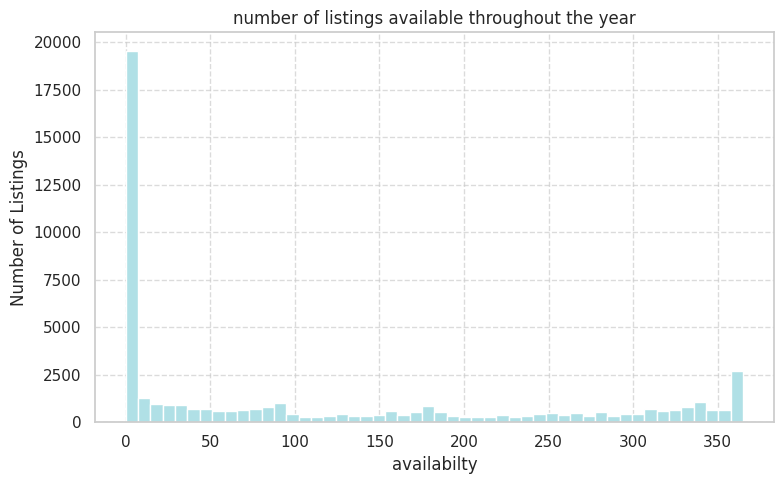

In [ ]:
# Chart - 14 visualization code

#number of listings available throughout the year

plt.figure(figsize=(8, 5))

plt.hist(df['availability_365'], bins=50, color='powderblue', edgecolor='white')
plt.title('number of listings available throughout the year')
plt.xlabel('availabilty')
plt.ylabel('Number of Listings')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

 histogram effectively visualizes the distribution of a continuous variable — in this case, availability_365, which shows the number of days per year a listing is available to book.

##### 2. What is/are the insight(s) found from the chart?

A big spike at 365 days — many listings are available year-round, suggesting full-time or commercial hosts.

Another peak at 0 or low availability — these could be due to : Inactive listings , Blocked calendars and Just-for-show/test listings

A scattered spread in the mid-range (50–300 days) indicating part-time or seasonal hosts who may block out certain months or host during holidays.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Airbnb can predict how much inventory is truly bookable in each season.

Avoid promoting listings with very low availability, which may frustrate guests.

A high number of listings with 0 or extremely low availability could signal: Abandoned listings , Poor host engagement and Fake listings or calendar mismanagement.

#### Chart - 15

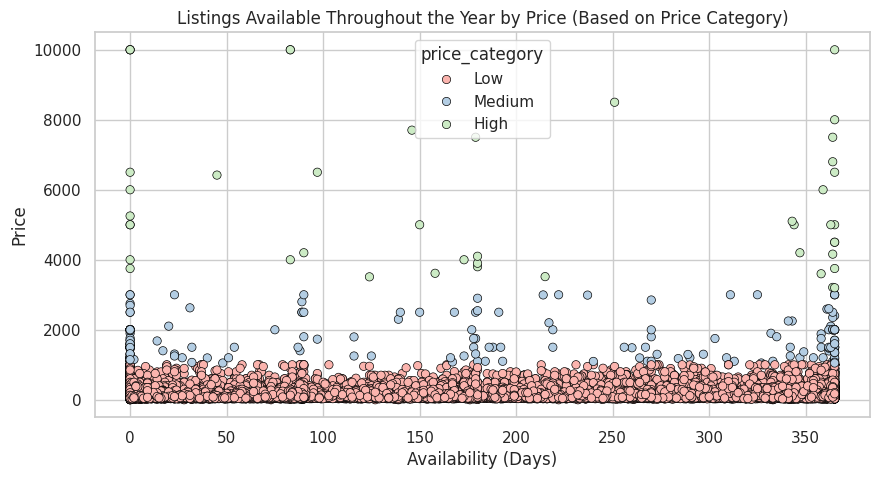

In [ ]:
# Chart - 15 visualization code

#listings available throughout year by price (based on price category)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='availability_365', y='price',palette='Pastel1',hue='price_category',edgecolor='black')
plt.title("Listings Available Throughout the Year by Price (Based on Price Category)")
plt.xlabel("Availability (Days)")
plt.ylabel("Price")
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plot perfectly shows the relationship between two continuous variables — availability_365 (x-axis) and price (y-axis)


##### 2. What is/are the insight(s) found from the chart?

A large cluster of low to medium-priced listings with availability close to 365 days — this shows many budget/mid-tier hosts keep their properties open year-round (possibly full-time income).

High-priced listings are more scattered, and many have lower availability, which could mean: Luxury/vacation homes rented only during peak seasons and hosts maintaining exclusivity or using platforms selectively

There may be no strong linear relationship between price and availability overall, but pattern differences appear across categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Airbnb can help luxury hosts maximize visibility during the limited times they’re available.

Suggest to low-availability, low-priced listings to increase calendar openness to boost bookings.

High-priced listings with very limited availability might annoy users if they appear in search results but aren’t bookable often

#### Chart - 16

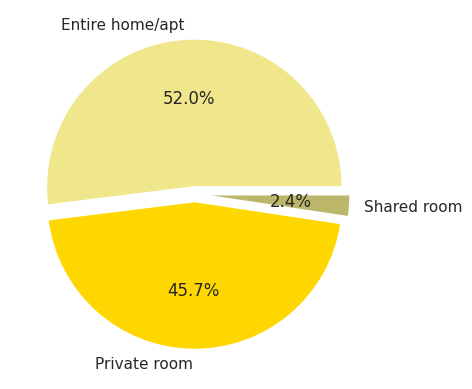

In [ ]:
# Chart - 16 visualization code

#distribution of room_type

k=df['room_type'].value_counts().keys()
v=df['room_type'].value_counts()
plt.pie(v,labels=k,autopct='%0.1f%%',colors=['khaki',  'gold','darkkhaki'],
    explode=[0.05]*len(k))

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart expresses a part-to-whole relationship in your data. It's easy to explain the percentage comparison through area covered in a circle with different colors. Where differenet percentage comparison comes into action pie chart is used frequently. So, I used Pie chart and which helped me to get the percentage comparision of the dependant variable.

##### 2. What is/are the insight(s) found from the chart?

Entire home/apt and private room are preferred more over shared room with percentage less than 2.5%

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Through this data we can say that running airbnbs with entire home/apt and private room available is more profitable than running shared room air bnbs.

The reason why shared rooms are preferred least is privacy.
Youngsters these days prefer privacy more than anything else.

#### Chart - 17

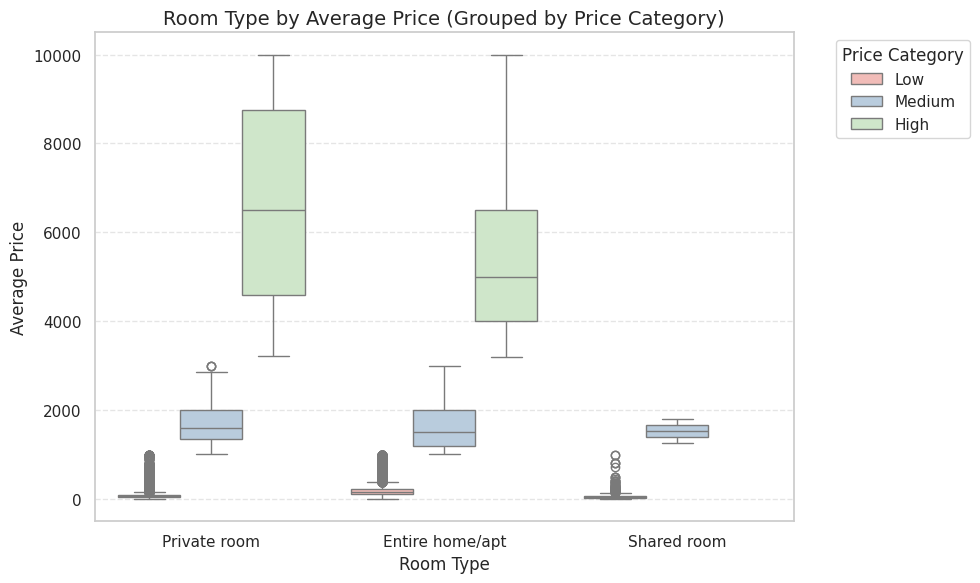

In [ ]:
# Chart - 17 visualization code

#room type by Price (Based on Price Category)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='room_type',
    y='price',
    hue='price_category',
    palette='Pastel1',

)

plt.title("Room Type by Average Price (Grouped by Price Category)", fontsize=14)
plt.xlabel("Room Type", fontsize=12)
plt.ylabel("Average Price", fontsize=12)
plt.legend(title="Price Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

boxplot is perfect for this scenario because:

It shows the median, interquartile range, and outliers of price for each room_type

It uses hue='price_category' to categorize listings into Low, Medium, and High tiers

This gives a multi-layered understanding: not just which room types are more expensive, but how much variation there is within each category

##### 2. What is/are the insight(s) found from the chart?

Entire home/apartment listings clearly have the highest prices, with a wide range and lots of high-value outliers in the "High" category.

Private rooms generally sit in the Low to Medium price range, with a more compact spread — they’re more consistent and affordable.

Shared rooms, if present in the dataset, are priced very low and show minimal variation, staying firmly in the Low price category.

There's a clear pattern where room type heavily influences pricing, and price categories align accordingly — i.e., it’s rare to see a shared room in the high-price category.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps hosts understand where their listing stands and price competitively within their room type.

Airbnb can better filter and present listings that match user budget + room preference.

Too many price outliers might indicate a need for platform-level price correction nudges or data cleaning to avoid misleading users.

#### Chart - 18

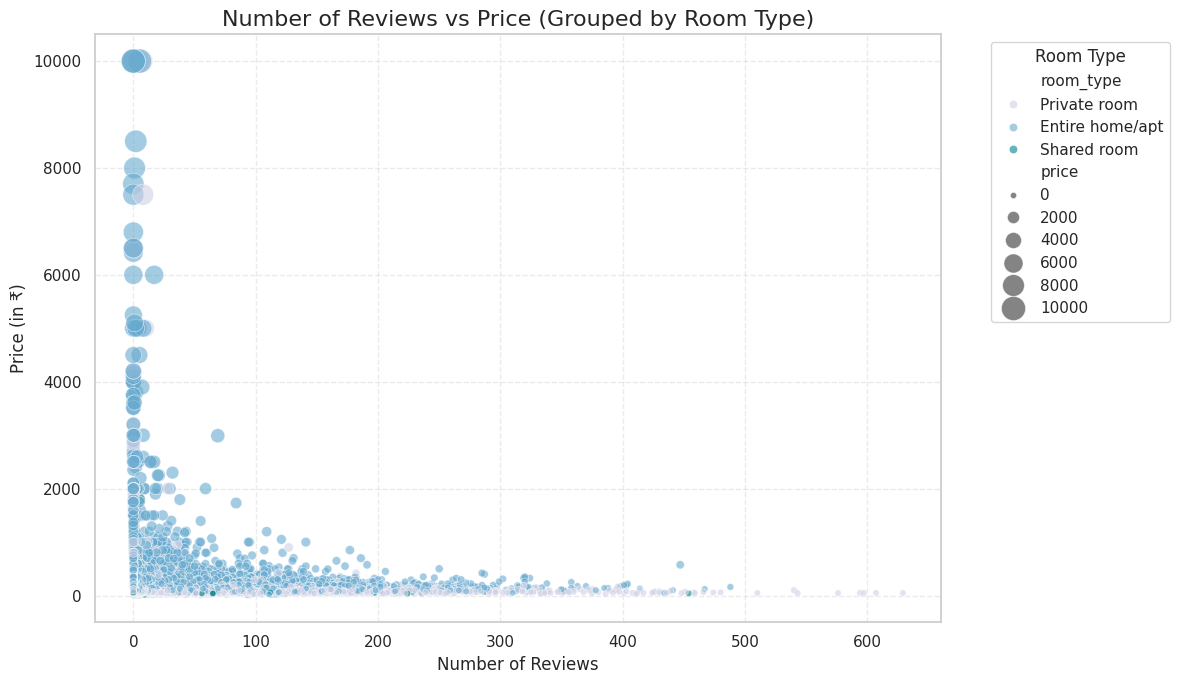

In [ ]:
# Chart - 18 visualization code

# number_of_reviews by Price (Grouped by room type

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='number_of_reviews',
    y='price',
    hue='room_type',
    palette='PuBuGn',
    size='price',
    sizes=(20, 300),
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

plt.title("Number of Reviews vs Price (Grouped by Room Type)", fontsize=16)
plt.xlabel("Number of Reviews", fontsize=12)
plt.ylabel("Price (in ₹)", fontsize=12)
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

scatter plot here because it’s perfect for visualizing relationships between two continuous variables:
number_of_reviews (x-axis) and price (y-axis)

##### 2. What is/are the insight(s) found from the chart?

Private rooms dominate the lower price range but have lots of reviews, suggesting they’re very popular among guests due to affordability.

Entire home/apartment listings appear more in the higher price ranges, but many have fewer reviews, hinting at either: Less frequent bookings or Newer listings or More exclusive use

Shared rooms (if visible) are rare, clustered at the low-price end with varying review activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Hosts can see what pricing is working for their room type and aim for optimal pricing + engagement.

Can better predict which listings are underpriced or overpriced based on review volume vs price.

Could signal uncompetitive pricing, especially for certain entire home/apartment listings that are underperforming.

#### Chart - 19 - Correlation Heatmap

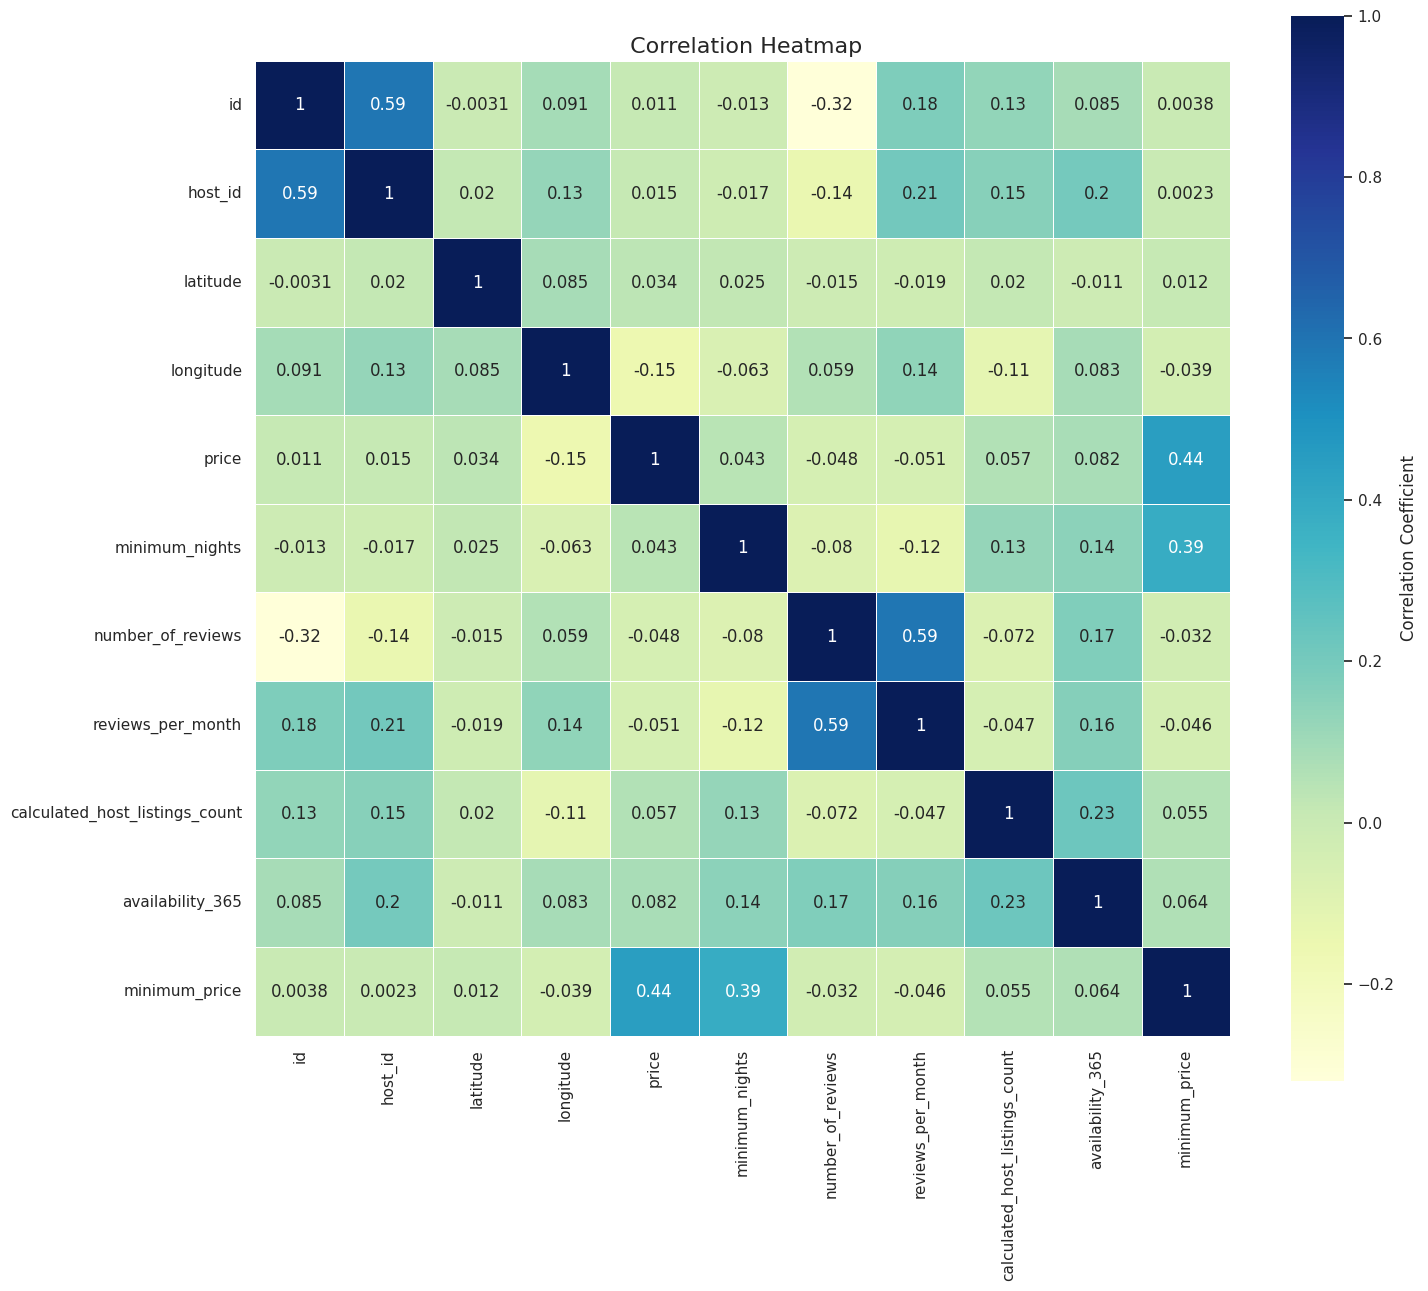

In [ ]:
# Correlation Heatmap visualization code
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(
    correlation_matrix,
    annot=True,         # Shows the correlation values
    cmap='YlGnBu',    # Color scheme (can change to 'viridis', 'magma', 'YlGnBu', etc.)
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

plt.title(" Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Correlation is a measure of how two numeric variables move together.

correlation heatmap :
It’s a color-coded table that shows the strength and direction of the correlation between all numeric columns in your dataset.



##### 2. What is/are the insight(s) found from the chart?

correlation heatmap shows how strongly numeric features in dataset relate to one another — from -1 to +1.

The correlation heatmap revealed that while *number_of_reviews* and *reviews_per_month* are strongly correlated, most other features showed weak or no correlation with price, suggesting that pricing is influenced by non-numeric factors like room type or location.

*Availability_365* showed a moderate positive relationship with *reviews_per_month*, indicating that highly available listings tend to be booked more frequently.

#### Chart - 20 - Pair Plot

/tmp/ipython-input-64-1874215936.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


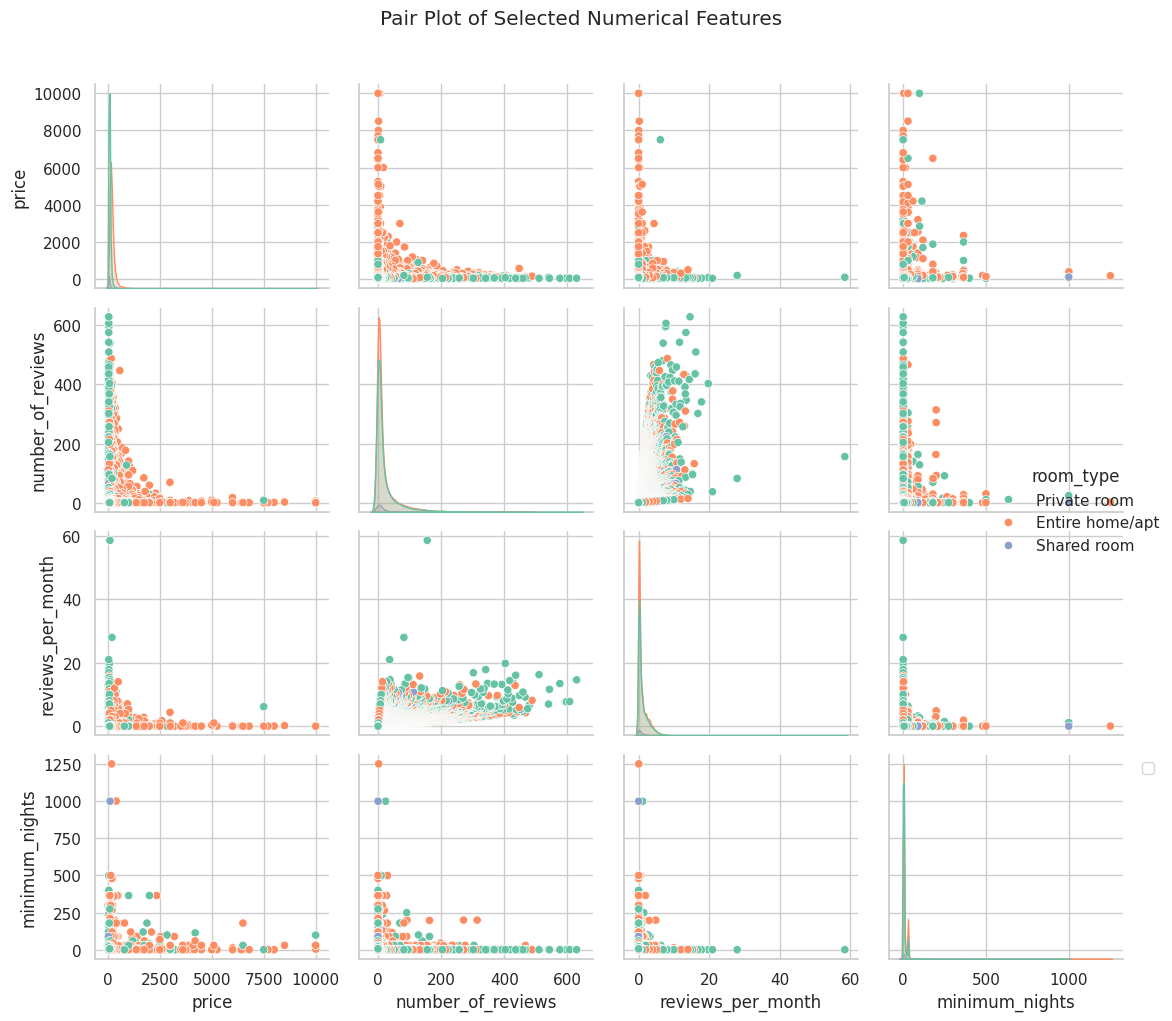

In [ ]:
# Pair Plot visualization code

sns.pairplot(
    df[['price', 'number_of_reviews', 'reviews_per_month', 'minimum_nights', 'room_type']],
    hue='room_type',
    palette='Set2'
)
plt.suptitle("Pair Plot of Selected Numerical Features", y=1.02)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot is used to understand the best set of features to explain a relationship between two variables or to form the most separated clusters. It also helps to form some simple classification models by drawing some simple lines or make linear separation in our data-set.

Thus, I used pair plot to analyse the patterns of data and realationship between the features. It's exactly same as the correlation map but here you will get the graphical representation.

##### 2. What is/are the insight(s) found from the chart?

 1. Price vs Number of Reviews (based on rooom_type)

* Entire home/apt	High price, but fewer reviews,guests may book longer but less frequently
*   Private room	Lower price + higher review count ,more turnover, booked frequently
*  Shared room	Dirt cheap, but also very few listings/reviews — not popular

2. Price vs Reviews per Month
* Listings with higher reviews/month are mostly lower-priced (esp. private rooms)
* Very expensive listings rarely get frequent reviews — maybe booked occasionally for luxury stays

3. Minimum Nights vs Price
* Listings with high minimum nights (50+ or 100+) are usually expensive entire homes
* Shared and private rooms cluster around 1–5 nights minimum
* Suggests business hosts prefer long-term guests for expensive homes

4. Number of Reviews vs Reviews per Month
* Strong linear trend: more total reviews = higher monthly reviews (duh, but it shows that the listing is consistently popular)
* Private/shared rooms dominate this area — probably cheaper and better located


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.



*  Use price distribution and room-type analysis to suggest ideal price ranges per neighbourhood.
*  Flag overpriced low-engagement listings and recommend adjustments.
* Promote Airbnb’s Smart Pricing tool based on demand trends and competitor pricing.

* Identify high-quality listings with low visibility or review counts and promote them via search ranking boosts or featured sections.
* Encourage inactive or low-availability hosts to open more calendar dates by showing missed revenue estimates.

* Promote listing types (e.g., private rooms, entire apartments) based on what guests prefer in each neighbourhood.
* Suggest hosts diversify offerings in underserved price categories (e.g., few budget listings in luxury areas or vice versa).

* Use monthly review trends to guide hosts on when to expect high demand, and suggest promotional campaigns or calendar openings.

* Help Airbnb target marketing campaigns during peak seasons to drive more traffic to active listings.

* Identify and address listings with: Extreme minimum_nights , Unavailable calendars and Unrealistic prices










# **Conclusion**

This analysis successfully uncovered trends in Airbnb listings that can inform:



* Travelers: Where to find affordable or premium stays
* Hosts: how pricing and availability affect visibility and reviews
* Platform managers or marketers: Which neighborhoods or room types are under-supplied/
over-supplied

The project demonstrates how raw data can be transformed into actionable knowledge using data science techniques. The insights gained can be utilized for revenue optimization, enhancing customer experience, and developing smarter urban tourism strategies.

Entire homes/apartments dominate the higher price range, while private rooms are more affordable and receive more reviews, indicating high popularity.

Most listings are available year-round, but a significant portion have limited availability, suggesting missed revenue opportunities.

Price and minimum nights do not follow a strict pattern, but longer stay requirements tend to appear more in higher-priced listings.

Monthly trends in reviews highlight seasonal booking behavior, which can be leveraged for strategic marketing and dynamic pricing.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***